In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [4]:
df = pd.read_csv('/workspaces/SML/SML /wdbc.data',header=None)

In [5]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
# split into features and target
x = df.iloc[:,2:].values
y = df.iloc[:,1].values

In [7]:
#Label Encoding
le = LabelEncoder()
y = le.fit_transform(y)

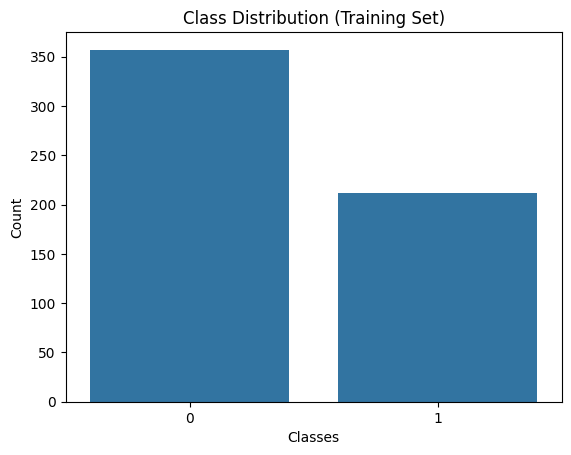

In [13]:
#check if any classimbalance there
sns.countplot(x=y)
plt.title("Class Distribution (Training Set)")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()


In [14]:
#training and testing the data
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=101)


Testing how the model performs for different hyperparameters -

1.Criterion
2.Max Depth
3.Max Features
4.Min leaf samples
5.Class weight ( if unbalanced )

**Criterion=entropy without class imbalance**

In [16]:
classifier = DecisionTreeClassifier(criterion='entropy',max_depth=4,class_weight='balanced',random_state=100)
classifier.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",100
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [17]:
y_pred1= classifier.predict(x_test)

In [18]:
classifier=DecisionTreeClassifier(criterion='gini',max_depth=4,random_state=67)
classifier.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",67
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [21]:
y_pred2 = classifier.predict(x_test)

In [22]:
acc1 = accuracy_score(y_test,y_pred1)
acc2 = accuracy_score(y_test,y_pred2)
print("Model 1 Accuracy:", acc1)
print("Model 2 Accuracy:", acc2)

Model 1 Accuracy: 0.956140350877193
Model 2 Accuracy: 0.9122807017543859


In [23]:
print("Classification Report: 1 ")
print(classification_report(y_test,y_pred1))

print("Classification Report: ")
print(classification_report(y_test,y_pred2))

Classification Report: 1 
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        72
           1       0.95      0.93      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Classification Report: 
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        72
           1       0.86      0.90      0.88        42

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114



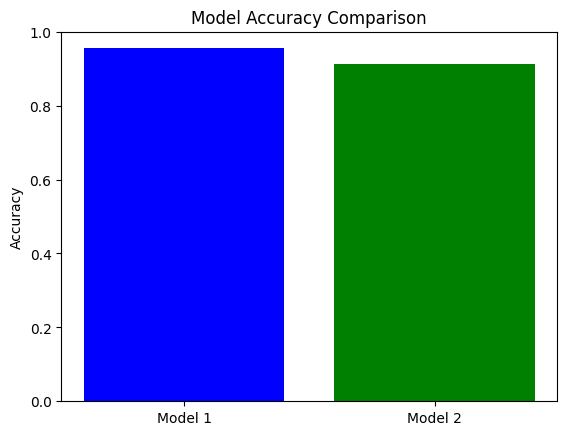

In [24]:
#comapring the accuracies
models = ['Model 1','Model 2']
accuracies = [acc1,acc2]
plt.bar(models,accuracies,color=['blue','green'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score
results = []
for depth in [2,6,9] :
  dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth= depth,
    class_weight= 'balanced',
    min_samples_leaf=6,
    random_state = 48)
  dt_model.fit(x_train,y_train)
  y_pred = dt_model.predict(x_test)
  results.append({
   'Max_depth' : depth,
   'Accuracy' : accuracy_score(y_test,y_pred),
   'Precision' : precision_score(y_test, y_pred),
   'Recall' : recall_score(y_test, y_pred)

})
df_results = pd.DataFrame(results)
print(df_results)
  


   Max_depth  Accuracy  Precision    Recall
0          2  0.938596   0.888889  0.952381
1          6  0.956140   0.930233  0.952381
2          9  0.956140   0.930233  0.952381


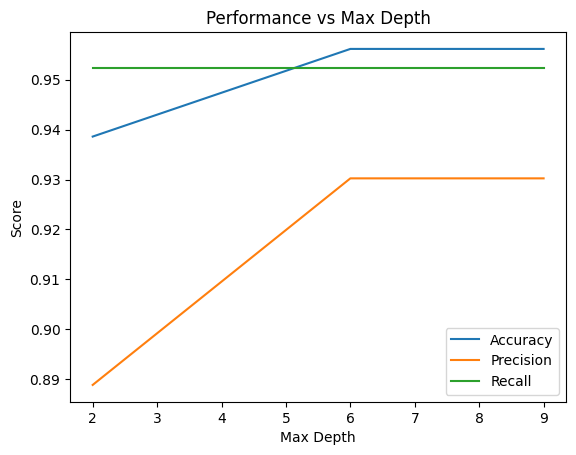

In [36]:
# PLotting the comparision in max depth

plt.plot(df_results['Max_depth'], df_results['Accuracy'], label='Accuracy')
plt.plot(df_results['Max_depth'], df_results['Precision'], label='Precision')
plt.plot(df_results['Max_depth'], df_results['Recall'], label='Recall')

plt.xlabel("Max Depth")
plt.ylabel("Score")
plt.legend()
plt.title("Performance vs Max Depth")
plt.show()


<Axes: xlabel='Max_depth', ylabel='Accuracy'>

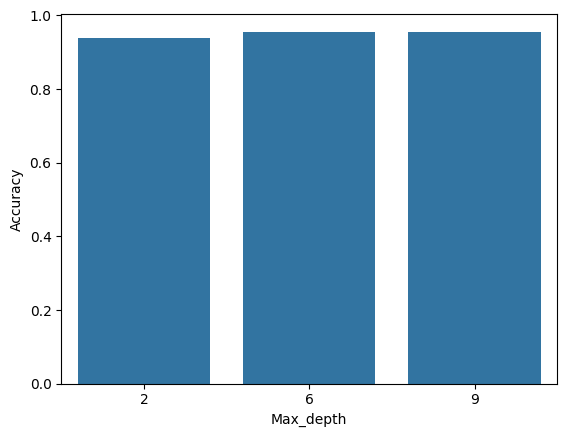

In [38]:
#Bar Plot
sns.barplot(x = 'Max_depth', y = 'Accuracy', data=df_results)

***PART 3 TEST AND TRAIN SIZES

In [41]:
training_result = []
accuracy_list = []
for i in [0.2,0.4,0.8]:
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=i,random_state=42)
    model = DecisionTreeClassifier(criterion = 'entropy',max_depth=4,class_weight='balanced',random_state=42)
    model.fit(x_train,y_train)
    y_pred_test = model.predict(x_test)
    y_pred_train = model.predict(x_train)

    train_acc = accuracy_score(y_train,y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    training_result.append({
        'Test Size' : i,
        'Accuracy' : test_acc,
        'Precision' : precision_score(y_test, y_pred_test),
        'Recall' : recall_score(y_test, y_pred_test),
        'F1 score' : f1_score(y_test, y_pred_test)

    })
    accuracy_list.append({
        'Test Size': i,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc
    })
training_result = pd.DataFrame(training_result)
accuracy_result = pd.DataFrame(accuracy_list)
print("Evaluation metrics:")
print(training_result)
print("\n")
print("\nTrain vs Test Accuracy:")
print(accuracy_result)

Evaluation metrics:
   Test Size  Accuracy  Precision    Recall  F1 score
0        0.2  0.956140   0.975000  0.906977  0.939759
1        0.4  0.960526   0.973333  0.912500  0.941935
2        0.8  0.905702   0.855491  0.891566  0.873156



Train vs Test Accuracy:
   Test Size  Train Accuracy  Test Accuracy
0        0.2        0.991209       0.956140
1        0.4        0.991202       0.960526
2        0.8        1.000000       0.905702


In [43]:
# Best accuracy based on the test size

best = accuracy_result.loc[accuracy_result['Test Accuracy'].idxmax()]

print("\nBest Test Size Based on Test Accuracy:")
print(best)


Best Test Size Based on Test Accuracy:
Test Size         0.400000
Train Accuracy    0.991202
Test Accuracy     0.960526
Name: 1, dtype: float64


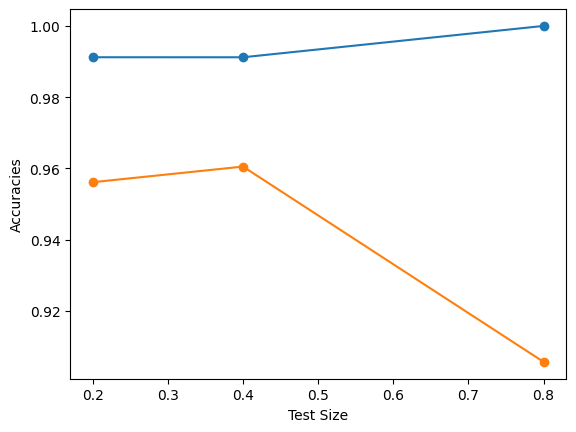

In [44]:
plt.plot(
    accuracy_result['Test Size'],
    accuracy_result['Train Accuracy'],
    marker = 'o',
    label = 'Train Accuracy'
)
plt.plot(
    accuracy_result['Test Size'],
    accuracy_result['Test Accuracy'],
    marker = 'o',
    label = 'Test Accuracy'
)
plt.xlabel('Test Size')
plt.ylabel('Accuracies')
plt.show()

